# 10.1 — AML real-data comparison: native Decipher vs `decipher_zx2` (model 5)

Two arms, three fits, on GSE298955 — which is the Decipher paper's **own** AML deposit
(Nazaret et al., *Genome Biology* 2025, doi `10.1186/s13059-025-03682-8`).

| fit | samples | `batch_key` | levels | what batch means |
|---|---|---|---|---|
| **C1** | AML1 `batch == 2` (`AML1sorted2_1`/`_2`) + BM_control | `library` | 3 | two lanes of one prep — **pure nuisance** |
| **C2** | AML2 `batch == 1` (`AML2sorted_1`/`_2`) + BM_control | `library` | 3 | two lanes of one prep — **pure nuisance** |
| **E**  | AML1 + AML2 + AML3 + BM_control | `patient` | 4 | patient — **confounded with disease** |

**Why C1 and C2 are not optional.** E on its own cannot distinguish "conditioning on a
confounded label deleted disease signal" from "`decipher_zx2` is just worse at this scale."
C1/C2 hold biology fixed so batch is nuisance by construction; they are the baseline E's
result is read against.

```
                   C1/C2 (nuisance)   E (confounded)
model5 >= native          OK               fails      -> the confound did it   <- the finding
model5 >= native          OK               OK         -> correction is safe here
model5 <  native         fails             fails      -> scale problem, not confounding
```

**Arms.** `native-decipher/decipher` (control, no batch mechanism — its `DecipherConfig` has
no batch field at all) and `model5/decipher_zx2`, which takes the batch one-hot into both
`encoder_x_to_z` (`context_dim=n_batches`) and `decoder_z_to_x`.

**beta = 0.001**, matching the paper's own TET2 cohort fit (Fig. S3c Methods). Note the paper
has three different betas: `1.0` is the default in `decipher_code/decipher_model.py` used by
the per-patient Fig. 4 fits, `0.001` for the TET2 cohort, `0.01` for TET2+DNM combined. Our
released packages default to `0.1`. None of these are interchangeable.

**Training settings are the paper's**, read off its only visible AML training call
(`analysis-aml13-17.ipynb`): `batch_size=512`, `learning_rate=1e-2`, `n_epochs=61`. Those are
very different from our packages' defaults (64 / 5e-3 / 1000 with early stopping), and the
difference is most of the runtime.

**Budget: 5 h CPU. Measured at 0.51 h** for all six runs (2 arms x 3 fits), no subsampling,
all 59,499 cells of E, all 5,363 genes. Measured on C2 at the paper's settings: 1.91 s/epoch,
against 3.53 s/epoch at `batch_size=64`.

Because that leaves so much room, this runs **3 seeds** (~1.5 h), so differences can be read
against seed-to-seed spread instead of being merely directional. §5.5 of
`batch_shift_review_handoff.md` is the reason: the simulated sweeps stayed directional at
n = 3 precisely because spread was never measured alongside the effect.

**No subsampling.** `load_datasets` has a `subsample` parameter (L11), but no notebook in
`decipher_reproducibility` ever passes it — the only `subsample` hits in that repo are an
unrelated local helper in `EDF 1.ipynb` and the `n_obs=2000` inside the metric itself. So the
paper trained on every cell, and so do we.

**One thing that cannot be matched.** The paper's published gene counts (3130 for
AML1+normal) are unreachable: the DE-selection step is commented out in the released loader
(section 5). Its actual filters yield **5,363 genes**. Do not use 3130 as a checksum.

Section 7 re-derives the budget from whatever your run actually produces.

**One seed.** Three seeds of E alone is ~8 h. So this run is directional: it can say model5
scored higher or lower, not that the difference exceeds run-to-run spread. Report it that way.

## 0. Configuration

No hardcoded paths. Everything derives from `REPO`, which is found by walking up for the
repo markers, or set directly with the `DECIPHER_BC_ROOT` environment variable. Each
directory and each knob has its own override, so moving this to GCP is environment variables
only — no edits to the notebook.

```bash
# example GCP invocation
export DECIPHER_BC_ROOT=/home/jupyter/decipher-bc-methods
export AML_DATA_DIR=/mnt/disks/data/aml          # where GSE298955_RAW.tar lives
export AML_OUT_DIR=/mnt/disks/data/aml_outputs
export DECIPHER_DEVICE=cuda                      # both arms accept device=
export DECIPHER_EPOCHS=200
```

In [ ]:
import os
import sys
import tarfile
import time
import warnings
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp

warnings.filterwarnings("ignore", category=FutureWarning)
sc.settings.verbosity = 1


def find_repo_root() -> Path:
    """Repo root from $DECIPHER_BC_ROOT, else walk up looking for the repo's markers."""
    env = os.environ.get("DECIPHER_BC_ROOT")
    if env:
        return Path(env).expanduser().resolve()
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "native-decipher").is_dir():
            return cand
    raise RuntimeError(
        "Could not locate the repo root. Set DECIPHER_BC_ROOT to the directory "
        "containing pyproject.toml and native-decipher/."
    )


REPO      = find_repo_root()
DATA_DIR  = Path(os.environ.get("AML_DATA_DIR", REPO / "Data" / "AML Data")).expanduser()
TAR_PATH  = Path(os.environ.get("AML_TAR", DATA_DIR / "GSE298955_RAW.tar")).expanduser()
WORK_DIR  = Path(os.environ.get("AML_WORK_DIR", DATA_DIR / "extracted")).expanduser()
CACHE_DIR = Path(os.environ.get("AML_CACHE_DIR", DATA_DIR / "h5ad_cache")).expanduser()
OUT_DIR   = Path(os.environ.get("AML_OUT_DIR", REPO / "Real Data" / "AML" / "aml_outputs")).expanduser()

# this notebook's own directory, for importing location_score.py that sits beside it
NB_DIR = Path(os.environ.get("AML_NB_DIR", REPO / "Real Data" / "AML")).expanduser()

for d in (WORK_DIR, CACHE_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- knobs -------------------------------------------------------------------
# Training settings are the paper's, from its only visible AML training call:
# analysis-aml13-17.ipynb -> train_simple(..., learning_rate=1e-2, batch_size=512, n_epochs=61)
# These are NOT our packages' defaults (64 / 5e-3 / 1000 epochs + early stopping).
DEVICE     = os.environ.get("DECIPHER_DEVICE", "cpu")
N_EPOCHS   = int(os.environ.get("DECIPHER_EPOCHS", "61"))
BATCH_SIZE = int(os.environ.get("DECIPHER_BATCH_SIZE", "512"))
LR         = float(os.environ.get("DECIPHER_LR", "1e-2"))
DIM_Z      = int(os.environ.get("DECIPHER_DIM_Z", "10"))       # paper's latent_dim
BETA       = float(os.environ.get("DECIPHER_BETA", "0.001"))   # paper Fig. S3c cohort fit

# Seeds. The measured cost is ~0.5 h for all six runs at one seed, so three is affordable
# and turns "model5 scored higher" into "by more than the seed-to-seed spread."
SEEDS = [int(s) for s in os.environ.get("DECIPHER_SEEDS", "0,1,2").split(",")]

# load_data.py defaults, reproduced exactly (decipher_code/load_data.py L8-10)
MIN_CELLS  = int(os.environ.get("AML_MIN_CELLS", "100"))
MIN_COUNTS = int(os.environ.get("AML_MIN_COUNTS", "500"))
TARGET_SUM = float(os.environ.get("AML_TARGET_SUM", "10000"))

# Budget gate (section 7). 5 h CPU for 2 arms x 3 fits x len(SEEDS).
MAX_HOURS = float(os.environ.get("AML_MAX_HOURS", "5.0"))

# load_data.py L11 `subsample` exists but is never passed by any notebook in
# decipher_reproducibility, so the paper trained on every cell. 0 = off, matching that.
SUBSAMPLE_CAP = int(os.environ.get("AML_SUBSAMPLE", "0"))

# Cells the Methods remove. Per-patient fits drop erythrocytes + lymphocytes; the cohort
# fit (Fig. S3c) additionally drops MEP. We apply the cohort rule everywhere so that C1,
# C2 and E see the same cell-type universe.
DROP_CELL_TYPES = ("lympho", "ery", "mep")

sys.path.insert(0, str(NB_DIR))     # location_score.py
sys.path.insert(0, str(REPO / "model5"))   # decipher_zx2 is not pip-installed; native is

print("REPO     :", REPO)
print("TAR      :", TAR_PATH, "->", "found" if TAR_PATH.exists() else "MISSING")
print("WORK_DIR :", WORK_DIR)
print("OUT_DIR  :", OUT_DIR)
print(f"device={DEVICE}  epochs={N_EPOCHS}  batch_size={BATCH_SIZE}  lr={LR}  "
      f"beta={BETA}  dim_z={DIM_Z}  seeds={SEEDS}")

## 1. Unpack

The archive is flat: 30 entries, `GSM<id>_<SAMPLE>_{counts,meta}.csv.gz`. We only need four
of the fifteen samples, so extract selectively.

**Which four, and why those.** `compute_location_score` needs the paper's manual leukemic
staging — `cell_type_merged` in `{immature, blast0, blast1, blast2, blast3}`. That annotation
ships as a `blast_cell_type_AML<n>` column for **AML1–AML4 only**. AML5 onward carry a single
undifferentiated `blast` label, so the metric's chain collapses and the score measures
nothing. BM_control supplies the `normal` side (its `cell_type` has 4,903 `immature` cells,
which the metric then splits by CD34 and MPO).

In [ ]:
SAMPLES = {
    # GEO sample : (GSM accession, load_data.py key, origin for the metric)
    "AML1":       ("GSM9027010", "p89",     "perturbed"),
    "AML2":       ("GSM9027011", "tet2_p1", "perturbed"),
    "AML3":       ("GSM9027012", "tet2_p3", "perturbed"),
    "BM_control": ("GSM9027024", "healthy", "normal"),
}

wanted = set()
for name, (gsm, _, _) in SAMPLES.items():
    wanted.add(f"{gsm}_{name}_counts.csv.gz")
    wanted.add(f"{gsm}_{name}_meta.csv.gz")

missing = [f for f in wanted if not (WORK_DIR / f).exists()]
if missing:
    if not TAR_PATH.exists():
        raise FileNotFoundError(f"{TAR_PATH} not found. Set AML_TAR or AML_DATA_DIR.")
    t0 = time.time()
    with tarfile.open(TAR_PATH) as tf:
        for m in tf.getmembers():
            base = Path(m.name).name
            if base in wanted and not (WORK_DIR / base).exists():
                with tf.extractfile(m) as src, open(WORK_DIR / base, "wb") as out:
                    out.write(src.read())
                print("  extracted", base)
    print(f"done in {time.time() - t0:.0f}s")
else:
    print("already extracted in", WORK_DIR)

for f in sorted(wanted):
    p = WORK_DIR / f
    print(f"  {f:44s} {p.stat().st_size / 1e6:8.1f} MB")

## 2. Read the counts

The counts CSVs are **cells x genes** — row index is the cell barcode, header is gene
symbols. AML1 is 37,395 x 18,131, which pandas would materialise as a ~5 GB dense float64
frame, so read it in chunks and convert each chunk to sparse. Result is cached as `.h5ad`
so a re-run is seconds rather than minutes.

`.X` is left as **raw integer counts** here. All normalisation happens in section 5, in the
order `load_data.py` does it.

In [ ]:
def read_counts_csv(path: Path, chunksize: int = 2000):
    """One GSE298955 counts CSV (cells x genes) -> (csr matrix, cell index, gene names)."""
    blocks, index, columns = [], [], None
    for chunk in pd.read_csv(path, index_col=0, chunksize=chunksize):
        if columns is None:
            columns = list(chunk.columns)
        index.extend(chunk.index.astype(str))
        blocks.append(sp.csr_matrix(chunk.to_numpy(dtype=np.float32)))
    return sp.vstack(blocks, format="csr"), index, columns


def load_sample(name: str) -> ad.AnnData:
    cache = CACHE_DIR / f"{name}.raw.h5ad"
    if cache.exists():
        return sc.read_h5ad(cache)

    gsm = SAMPLES[name][0]
    t0 = time.time()
    X, cells, genes = read_counts_csv(WORK_DIR / f"{gsm}_{name}_counts.csv.gz")
    meta = pd.read_csv(WORK_DIR / f"{gsm}_{name}_meta.csv.gz", index_col=0)
    meta.index = meta.index.astype(str)

    if list(meta.index) != list(cells):
        common = [c for c in cells if c in set(meta.index)]
        if len(common) != len(cells):
            print(f"  {name}: {len(cells) - len(common)} cells missing from meta, dropped")
        keep = np.array([c in set(meta.index) for c in cells])
        X, cells = X[keep], [c for c, k in zip(cells, keep) if k]
        meta = meta.loc[cells]

    a = ad.AnnData(X=X, obs=meta.copy(), var=pd.DataFrame(index=pd.Index(genes)))
    a.var_names_make_unique()
    a.write_h5ad(cache, compression="gzip")
    print(f"  {name}: {a.shape[0]:,d} cells x {a.shape[1]:,d} genes  ({time.time() - t0:.0f}s)")
    return a


raw = {name: load_sample(name) for name in SAMPLES}
for n, a in raw.items():
    print(f"{n:12s} {a.shape}")

## 3. Labels

Three sets of columns, kept deliberately separate.

**For the metric.** `origin` must be exactly `normal` / `perturbed`, and `cell_type_merged`
must hold the staging. `load_data.py` L44-60 maps each dataset to its own cell-type column;
GEO renames those to the paper's sample numbering, so the mapping becomes:

| `load_data.py` L44-60 | GEO column | our sample |
|---|---|---|
| `p89` -> `blast_cell_type_08H089` | `blast_cell_type_AML1` | AML1 |
| `tet2_p1` -> `blast_cell_type_16H008` | `blast_cell_type_AML2` | AML2 |
| `tet2_p3` -> `blast_cell_type_AML7` | `blast_cell_type_AML3` | AML3 |
| `healthy` -> `cell_type` | `cell_type` | BM_control |

(The BCLQ id for AML3 is the literal string `AML7`, which is a *different patient* from
GEO's AML7. Do not let those collide.)

**For the batch keys.** `library` is the GEO `sample` column — one sequencing library.
`prep_batch` is the GEO `batch` column — the sort protocol. `patient` is the GEO sample name.

> **Deviation from `load_data.py`, deliberate.** L139 concatenates with
> `batch_key="sample"`, which would *overwrite* GEO's existing `sample` column and silently
> destroy the within-patient structure C1 and C2 depend on. We copy it to `library` first
> and concatenate without reusing that name.

> **Deviation, deliberate.** `load_data.py` L81 sets `obs["origin"]` to the dataset *key*
> (`p89`, `tet2_p1`, `healthy`). `compute_location_score` instead expects `normal` /
> `perturbed`, which is what the benchmark notebook's objects carry. We set `origin` to what
> the metric needs and keep the load_data-style key as `origin_key`.

In [ ]:
CELL_TYPE_COLUMN = {          # mirrors load_data.py L44-60, under GEO's column naming
    "AML1":       "blast_cell_type_AML1",
    "AML2":       "blast_cell_type_AML2",
    "AML3":       "blast_cell_type_AML3",
    "BM_control": "cell_type",
}

# load_data.py L67-74 -- columns forced to exist so concatenation does not drop them
OBS = ["cell_type", "NPM1_mut", "DNMT3A_mut", "DNMT3A_wt", "NPM1_wt", "phase"]

for name, a in raw.items():
    gsm, key, origin = SAMPLES[name]

    a.obs["origin_key"] = key                   # load_data.py L81 semantics
    a.obs["origin"] = origin                    # what compute_location_score reads
    a.obs["patient"] = name

    col = CELL_TYPE_COLUMN[name]
    if col not in a.obs:
        raise KeyError(f"{name}: expected column {col!r}; has {list(a.obs.columns)}")
    a.obs["cell_type_merged"] = a.obs[col].astype(str)     # load_data.py L92

    # GEO 'sample' = one sequencing library; renamed so concatenation cannot clobber it
    a.obs["library"] = a.obs["sample"].astype(str) if "sample" in a.obs else name
    a.obs["prep_batch"] = a.obs["batch"].astype(str) if "batch" in a.obs else "0"

    for c in OBS:                                          # load_data.py L94-96
        if c not in a.obs:
            a.obs[c] = "undefined"

    a.X = a.X.astype(float)                                # load_data.py L97

print("cell_type_merged values per sample")
for name, a in raw.items():
    vc = a.obs["cell_type_merged"].value_counts()
    print(f"  {name:12s} {dict(vc)}")
print()
print("library / prep_batch structure")
for name, a in raw.items():
    print(f"  {name:12s} libraries={a.obs['library'].nunique():2d}  prep_batches={a.obs['prep_batch'].nunique()}")
    print(f"               {dict(a.obs.groupby('prep_batch', observed=True)['library'].unique())}")

## 4. Remove erythrocytes, lymphocytes and MEP

From the Methods: *"We also removed erythrocytes and lymphocytes from the data, as they were
not relevant for the analysis of AML derailment"*, and for the cohort fit specifically,
*"with lymphoids, erythroids, and MEP cells removed."*

> **Not in `load_data.py`.** This step has no counterpart in the released loader — it was
> done upstream, on the authors' `_cleaned.h5` files. We apply it explicitly here.

Order matters: cells go first, so that the `filter_genes` calls in section 5 see the final
cell population. Two columns carry the labels — `cell_type` (`lympho`, `ery`, `mep`) and,
for AML1/2/3, an `ery` value inside `blast_cell_type_AML<n>`.

This deletes almost all of AML1's `batch == 4` (`AML1_Sorted_Double_P`), which is 99.2%
lymphocytes: 7,403 cells -> 55. That is expected, not a bug.

In [ ]:
before = {n: a.n_obs for n, a in raw.items()}
for name, a in list(raw.items()):
    keep = np.ones(a.n_obs, dtype=bool)
    if "cell_type" in a.obs:
        keep &= ~a.obs["cell_type"].astype(str).isin(DROP_CELL_TYPES).to_numpy()
    keep &= ~a.obs["cell_type_merged"].astype(str).isin(DROP_CELL_TYPES).to_numpy()
    raw[name] = a[keep].copy()

print(f"dropped {DROP_CELL_TYPES}")
for name, a in raw.items():
    print(f"  {name:12s} {before[name]:6,d} -> {a.n_obs:6,d}   "
          f"stages: {dict(a.obs['cell_type_merged'].value_counts())}")

## 5. Preprocess — mirroring `decipher_code/load_data.py`

Same operations, same order, same defaults as `load_datasets()`. Line references are to the
copy sitting beside this notebook (`Real Data/AML/load_data.py`), which is byte-identical to
the one in `decipher_reproducibility/decipher_code/`.

| step | `load_data.py` | reproduced |
|---|---|---|
| `X.astype(float)` | L97 | section 3 |
| `filter_genes(min_cells=100)` | L99 | below |
| `filter_genes(min_counts=500)` | L100 | below |
| gene intersection across datasets | L102-105 | below |
| drop `RPL*`, `RPS*`, `MT-*` | L113-115 | below |
| apply the intersection | L123 | below — **see the quirk** |
| `normalize_total(target_sum=10_000)` | L130-132 | below |
| concatenate with healthy | L139 | section 6 |
| `float64 -> int64 -> float64` | L142 | below |

**The quirk at L117-127, and which side of it we take.** The gene intersection is computed at
L102-105 but applied only *inside* the `if subsample is not None:` branch. Called without
`subsample`, the released loader **never subsets**, so `normalize_total` at L132 divides by
each cell's total over that dataset's **own** gene set — a different denominator than if the
intersection had been applied first. That changes every value, so it is a real fork.

No notebook in `decipher_reproducibility` passes `subsample`, so the paper took the
*un-subset* branch. `APPLY_INTERSECTION_BEFORE_NORMALIZE = False` reproduces it: normalise
per dataset over its own genes, then let the intersection take effect at concatenation
(section 6 joins on `inner`). Set it to `True` for the other branch.

**What we cannot reproduce.** The paper's final gene set is the top-400 differentially
expressed genes per PhenoGraph cluster pooled with marker genes. In the released loader that
step is the `genes.txt` intersection at **L110-111, which is commented out**, and the DE
helper `t_test_deg()` is never called from `load_datasets`. So the published counts (3130
genes for AML1+normal, 3264 for AML2, 3258 for AML3) are **not reachable from this code**.
Expect a different number and do not treat 3130 as a checksum.

In [ ]:
# False = the branch the paper actually took, since no notebook passes `subsample`.
APPLY_INTERSECTION_BEFORE_NORMALIZE = False   # see the quirk note above (load_data.py L117-127)

gene_intersection = None
for name, a in raw.items():
    sc.pp.filter_genes(a, min_cells=MIN_CELLS)      # load_data.py L99
    sc.pp.filter_genes(a, min_counts=MIN_COUNTS)    # load_data.py L100
    if gene_intersection is None:                   # load_data.py L102-105
        gene_intersection = set(a.var_names)
    else:
        gene_intersection.intersection_update(a.var_names)
    print(f"  {name:12s} after filter_genes: {a.shape}")

# load_data.py L113-115
print("\nRemoving genes starting with RPL*, RPS*, MT-*")
gene_intersection = filter(lambda x: x[:3] not in ["RPL", "RPS", "MT-"], gene_intersection)
gene_intersection = list(sorted(gene_intersection))
print(f"gene intersection: {len(gene_intersection):,d} genes")

for g in ("CD34", "MPO"):                           # compute_location_score needs both
    if g not in gene_intersection:
        raise RuntimeError(f"{g} did not survive gene filtering; the metric cannot run.")
print("CD34 and MPO both present.")

if APPLY_INTERSECTION_BEFORE_NORMALIZE:
    for name in list(raw):                          # load_data.py L123
        raw[name] = raw[name][:, gene_intersection].copy()

if TARGET_SUM is not None and TARGET_SUM > 0:       # load_data.py L130-132
    for name, a in raw.items():
        sc.pp.normalize_total(a, target_sum=TARGET_SUM)

for a in raw.values():                              # load_data.py L142
    a.X = (a.X.astype(np.float64)).astype(np.int64).astype(np.float64)

if not APPLY_INTERSECTION_BEFORE_NORMALIZE:
    for name in list(raw):
        raw[name] = raw[name][:, gene_intersection].copy()

N_GENES = len(gene_intersection)
for name, a in raw.items():
    print(f"  {name:12s} {a.shape}   X integer-valued: {np.allclose(a.X.data % 1, 0) if sp.issparse(a.X) else np.allclose(a.X % 1, 0)}")

## 6. Build the three fit objects

Concatenation with `anndata.concat` rather than the deprecated `.concatenate()`, and
**without** reusing the name `sample` as a batch key — see the deviation note in section 3.

`library` for C1/C2 gives three levels: the two lanes of the AML prep, plus BM_control.
Batch mixing is only meaningful *between the two AML lanes*, where it is pure nuisance;
BM_control is there so the metric has a `normal` side and can return `score_divergence`.

`join="inner"` is where the gene intersection from section 5 actually takes effect, which is
what the released loader does too — `.concatenate()` defaults to an inner join on vars.

`SUBSAMPLE_CAP` defaults to 0 (off), matching the paper. It is wired up only so a future run
that needs to fit a tighter budget has the knob; `load_data.py` L125-127 is the call it
mirrors.

In [ ]:
def build_fit(members: dict, batch_key: str) -> ad.AnnData:
    """members: {label -> AnnData subset}. Returns one concatenated object."""
    parts = []
    for label, a in members.items():
        b = a.copy()
        if SUBSAMPLE_CAP and b.n_obs > SUBSAMPLE_CAP:      # load_data.py L125-127; off by default
            sc.pp.subsample(b, n_obs=SUBSAMPLE_CAP, random_state=SEEDS[0])
            print(f"    subsampled {label}: {a.n_obs:,d} -> {b.n_obs:,d}")
        b.obs["fit_member"] = label
        parts.append(b)
    out = ad.concat(parts, join="inner", index_unique="-", label=None)
    out.obs[batch_key] = out.obs[batch_key].astype("category")
    out.obs["origin"] = out.obs["origin"].astype(str)
    out.obs["cell_type_merged"] = out.obs["cell_type_merged"].astype(str)
    if not sp.issparse(out.X):
        out.X = sp.csr_matrix(out.X)      # gene_marker() calls .X.toarray()
    return out


aml1_b2 = raw["AML1"][raw["AML1"].obs["prep_batch"] == "2"].copy()
aml2_b1 = raw["AML2"][raw["AML2"].obs["prep_batch"] == "1"].copy()

MEMBERS = {
    "C1": ({"AML1_b2": aml1_b2, "BM_control": raw["BM_control"]}, "library",
           "AML1 batch 2 (two lanes, same prep) + BM_control -- batch is pure nuisance"),
    "C2": ({"AML2_b1": aml2_b1, "BM_control": raw["BM_control"]}, "library",
           "AML2 batch 1 (two lanes, same prep) + BM_control -- batch is pure nuisance"),
    "E":  ({n: raw[n] for n in ["AML1", "AML2", "AML3", "BM_control"]}, "patient",
           "AML1+AML2+AML3+BM_control -- batch is patient, confounded with disease"),
}

FITS = {}
for name, (members, bk, note) in MEMBERS.items():
    print(f"{name}:")
    FITS[name] = dict(
        adata=build_fit(members, bk),
        batch_key=bk,
        note=note,
        member_sizes=[a.n_obs for a in members.values()],   # pre-cap, for the budget gate
    )

for k, f in FITS.items():
    a, bk = f["adata"], f["batch_key"]
    lv = list(a.obs[bk].cat.categories)
    print(f"{k}: {a.shape}  batch_key={bk!r}  levels={len(lv)} {lv}")
    print(f"    {f['note']}")
    print(f"    origin: {dict(a.obs['origin'].value_counts())}")
    print(f"    stages: {dict(a.obs['cell_type_merged'].value_counts())}")
    if (a.obs["origin"] == "normal").sum() == 0:
        print("    WARNING: no normal cells -> score_divergence will be NaN")
    if ((a.obs["origin"] == "perturbed") & (a.obs["cell_type_merged"] == "immature")).sum() == 0:
        print("    WARNING: no perturbed_immature cells -> score_divergence will be NaN")
    print()

## 7. Budget gate

Hard stop before any training. The rate constant is **measured on this data at the paper's
settings** — `decipher_zx2` on C2 (10,515 cells x 5,363 genes), `batch_size=512`, `lr=1e-2`:
**1.91 s/epoch**. At `batch_size=64` the same fit takes 3.53 s/epoch, so the batch size is
worth roughly 1.8x here.

`AML_RATE_S_PER_CELL_GENE_EPOCH` overrides it. On different hardware, measure rather than
trust this: train one fit for 5 epochs and divide.

In [ ]:
# seconds per cell per gene per epoch. Measured: 1.91 s/epoch on C2 at 10,515 x 5,363.
RATE = float(os.environ.get("AML_RATE_S_PER_CELL_GENE_EPOCH", 1.91 / (10515 * 5363)))
N_ARMS = 2

rows, total = [], 0.0
for k, f in FITS.items():
    n = f["adata"].n_obs
    hours = RATE * n * N_GENES * N_EPOCHS * N_ARMS * len(SEEDS) / 3600
    total += hours
    rows.append({"fit": k, "cells": n, "genes": N_GENES,
                 "levels": f["adata"].obs[f["batch_key"]].cat.categories.size,
                 "hours_all_arms_seeds": round(hours, 2)})
est = pd.DataFrame(rows)
print(est.to_string(index=False))
print(f"\nseeds={SEEDS}  epochs={N_EPOCHS}  batch_size={BATCH_SIZE}  lr={LR}  beta={BETA}")
print(f"projected total ({len(FITS) * N_ARMS * len(SEEDS)} training runs): "
      f"{total:.2f} h   budget: {MAX_HOURS:.1f} h")

if total > MAX_HOURS:
    per_seed = total / len(SEEDS)
    fits_seeds = int(MAX_HOURS // per_seed) if per_seed else 0
    raise RuntimeError(
        f"Projected {total:.2f} h exceeds the {MAX_HOURS:.1f} h budget at {N_GENES:,d} genes.\n"
        f"  Cheapest fix: drop to DECIPHER_SEEDS={','.join(str(s) for s in SEEDS[:max(1, fits_seeds)])} "
        f"({per_seed:.2f} h per seed).\n"
        f"  Then AML_SUBSAMPLE (load_data.py L11, off by default here) to cap cells per member.\n"
        f"  Do NOT raise AML_MIN_COUNTS past ~500: at 1000 the gene intersection loses CD34 "
        f"and MPO, and compute_location_score cannot run without them."
    )
print("within budget.")

## 8. Check the metric before spending four hours on it

`compute_location_score` is copied verbatim from the paper's own benchmark notebook into
`location_score.py` beside this notebook; `3-evaluate-metric.ipynb` is a verbatim copy of the
source. Only pandas-2.x compatibility edits were made, each with the original line left
commented in place.

This cell runs it on three synthetic layouts so you can see what the numbers do before
reading real ones:

- **correct** — AML root sits next to the healthy root, the leukemic arm extends away
- **collapsed** — the whole AML arm lies on top of the healthy cells (**over-correction**)
- **shifted** — the whole AML arm sits far away, root included (**no correction**)

Expected: ordering collapses under *collapsed*; divergence is highest for *correct* and worst
for *shifted*. Higher is better for both.

In [ ]:
from location_score import compute_location_score

def _metric_selfcheck(seed=0):
    rng = np.random.default_rng(seed)
    ct  = ["immature"] * 900 + ["immature"] * 500 + ["blast0"] * 500 + \
          ["blast1"] * 500 + ["blast2"] * 500 + ["blast3"] * 500
    org = ["normal"] * 900 + ["perturbed"] * 2500
    n, genes = len(ct), ["CD34", "MPO"] + [f"G{i}" for i in range(20)]
    A = ad.AnnData(
        X=sp.csr_matrix(rng.poisson(2, size=(n, len(genes))).astype(np.float32)),
        obs=pd.DataFrame({"origin": org, "cell_type_merged": ct},
                         index=[f"c{i}" for i in range(n)]),
        var=pd.DataFrame(index=genes),
    )
    stage = {"immature": 0, "blast0": 1, "blast1": 2, "blast2": 3, "blast3": 4}
    def layout(mode):
        p = []
        for o, c in zip(org, ct):
            if o == "normal":
                p.append([rng.normal(0.8, 0.5), 0.0])
            elif mode == "correct":
                p.append([stage[c], 0.0])
            elif mode == "collapsed":
                p.append([rng.normal(0.8, 0.5), 0.0])
            else:                                    # shifted
                p.append([stage[c], 4.0])
        return np.array(p) + rng.normal(0, 0.05, size=(n, 2))
    out = []
    for m in ["correct", "collapsed", "shifted"]:
        A.obsm[m] = layout(m)
        o, d = compute_location_score(A, m)
        out.append({"layout": m, "score_ordering": round(o, 4), "score_divergence": round(d, 4)})
    return pd.DataFrame(out)

print(_metric_selfcheck().to_string(index=False))
print("\nhigher is better for both. ordering should drop under 'collapsed';")
print("divergence should be best for 'correct' and worst for 'shifted'.")

## 9. Train

Six runs: two arms x three fits. Reload each fit object fresh per arm — `decipher_train`
writes into `obs`, `obsm` and `uns`, so the two arms would contaminate each other otherwise.

The call signatures differ, and that difference is the control:

- `native-decipher` has **no** `batch_key` parameter and no `n_batches` on its config. It
  ignores the batch column entirely. Passing `batch_key=` raises `TypeError`.
- `decipher_zx2` takes `batch_key=` and threads a one-hot into `encoder_x_to_z` and
  `decoder_z_to_x`.

`plot_kwargs={"color": [BATCH_KEY]}` with **list brackets** is required: the forked packages'
`plot/decipher.py` L189 still reads `len(color)` after L146-149 renamed it, so `None` raises
*after* training finishes and a bare string silently mislabels axes.

In [ ]:
import decipher as dc_native
import decipher_zx2 as dc_zx2

ARMS = {
    "native": dict(module=dc_native, takes_batch_key=False),
    "zx2":    dict(module=dc_zx2,    takes_batch_key=True),
}

def train_one(fit_name, arm_name, seed):
    f   = FITS[fit_name]
    bk  = f["batch_key"]
    arm = ARMS[arm_name]
    dc  = arm["module"]

    out_path = OUT_DIR / f"{fit_name}_{arm_name}_seed{seed}.h5ad"
    if out_path.exists():
        print(f"  {fit_name}/{arm_name}/seed{seed}: cached")
        return sc.read_h5ad(out_path)

    adata = f["adata"].copy()
    cfg = dc.tl.DecipherConfig(
        dim_z=DIM_Z, beta=BETA, learning_rate=LR, seed=seed,
        n_epochs=N_EPOCHS, batch_size=BATCH_SIZE,
    )
    kw = dict(plot_every_k_epochs=-2, plot_kwargs={"color": [bk]}, device=DEVICE)
    if arm["takes_batch_key"]:
        kw["batch_key"] = bk

    t0 = time.time()
    model, val = dc.tl.decipher_train(adata, cfg, **kw)
    msg = f"  {fit_name}/{arm_name}/seed{seed}: {(time.time() - t0) / 60:.1f} min"
    if arm["takes_batch_key"]:
        msg += f"  n_batches={model.config.n_batches} batch_key={model.config.batch_key}"
    print(msg)

    adata.write_h5ad(out_path, compression="gzip")
    return adata


trained = {}
wall0 = time.time()
for fit_name in ["C1", "C2", "E"]:          # cheap fits first: a pipeline bug costs minutes
    print(f"{fit_name} -- {FITS[fit_name]['note']}")
    for seed in SEEDS:
        for arm_name in ARMS:
            trained[(fit_name, arm_name, seed)] = train_one(fit_name, arm_name, seed)
print(f"\ntotal wall time: {(time.time() - wall0) / 3600:.2f} h")

## 10. Score

Two families, deliberately opposed.

**Mixing** — batch silhouette in each embedding, plus the X-space row as the "as given"
reference. Lower means batches are better mixed. On its own this metric **rewards
over-correction**: a model that collapses AML blasts onto healthy cells scores perfectly.

**Structure** — `score_ordering` and `score_divergence`. Higher is better. `score_divergence`
is the guard: the only adjacent cross-origin pair is `normal_stage1`-`perturbed_immature`, so
collapsing AML onto healthy inflates the subtracted term and the score falls.

For C1/C2, read the batch silhouette **between the two AML lanes only** — BM_control is a
third level there, and separating it from the AML lanes is correct biology, not a batch
effect left uncorrected.

In [ ]:
from sklearn.metrics import silhouette_score

SIL_SAMPLE = int(os.environ.get("AML_SIL_SAMPLE", "5000"))   # silhouette is O(n^2)

def batch_silhouette(adata, key, obsm_key, subset_mask=None):
    A = adata[subset_mask] if subset_mask is not None else adata
    codes = A.obs[key].astype("category").cat.codes.to_numpy()
    if len(np.unique(codes)) < 2:
        return np.nan
    return silhouette_score(A.obsm[obsm_key], codes,
                            sample_size=min(SIL_SAMPLE, A.n_obs), random_state=0)


def x_space_reference(adata, key, subset_mask=None):
    """Batch separation in the input, before any model touches it."""
    A = (adata[subset_mask] if subset_mask is not None else adata).copy()
    sc.pp.normalize_total(A, target_sum=1e4)
    sc.pp.log1p(A)
    sc.pp.pca(A, n_comps=50, svd_solver="arpack")
    codes = A.obs[key].astype("category").cat.codes.to_numpy()
    return silhouette_score(A.obsm["X_pca"], codes,
                            sample_size=min(SIL_SAMPLE, A.n_obs), random_state=0)


rows = []
for fit_name in ["C1", "C2", "E"]:
    bk = FITS[fit_name]["batch_key"]
    # for C1/C2 the nuisance contrast is the two AML lanes; BM_control is the anchor, and
    # separating it from them is correct biology, not an uncorrected batch effect
    aml_only = None
    ref = trained[(fit_name, "native", SEEDS[0])]
    if fit_name in ("C1", "C2"):
        aml_only = (ref.obs["origin"] == "perturbed").to_numpy()

    rows.append({
        "fit": fit_name, "arm": "(input data)", "space": "X (log-norm PCA)", "seed": -1,
        "sil_batch": round(x_space_reference(ref, bk, aml_only), 4),
        "score_ordering": np.nan, "score_divergence": np.nan,
    })
    for seed in SEEDS:
        for arm_name in ARMS:
            a = trained[(fit_name, arm_name, seed)]
            for space in ["decipher_v", "decipher_z"]:
                o, d = compute_location_score(a, space)
                rows.append({
                    "fit": fit_name, "arm": arm_name, "space": space, "seed": seed,
                    "sil_batch": round(batch_silhouette(a, bk, space, aml_only), 4),
                    "score_ordering": round(o, 4), "score_divergence": round(d, 4),
                })

results = pd.DataFrame(rows)
results.to_csv(OUT_DIR / "aml_results_per_seed.csv", index=False)

# mean +/- spread across seeds -- the spread is what makes a difference readable
METRICS = ["sil_batch", "score_ordering", "score_divergence"]
summary = (results[results.seed >= 0]
           .groupby(["fit", "arm", "space"])[METRICS]
           .agg(["mean", "std"]).round(4))
summary.to_csv(OUT_DIR / "aml_results_summary.csv")

print("PER SEED\n")
print(results.to_string(index=False))
print("\n\nACROSS SEEDS (mean, std)\n")
print(summary.to_string())
print("\nwrote", OUT_DIR / "aml_results_per_seed.csv")
print("wrote", OUT_DIR / "aml_results_summary.csv")

## 11. Read the table

Two questions, in this order.

**1. Does `zx2` hold up where batch is pure nuisance?** Look at C1 and C2. `sil_batch`
between the two AML lanes should be at or below native's, and `score_ordering` /
`score_divergence` should not be worse. If `zx2` loses here, stop — the E result cannot be
attributed to confounding, because the arm underperforms even when the batch label carries
no biology.

**2. Only if C1/C2 hold: what does E cost?** If `zx2` mixes patients better (lower
`sil_batch`) *and* keeps ordering and divergence, conditioning on a confounded label was
safe on this data. If `sil_batch` drops while `score_divergence` also drops, that is the
over-correction signature — the patients mixed because the disease signal went with them.

**Use the spread.** The summary table carries `std` across seeds beside every `mean`. A
difference between arms that is smaller than the seed-to-seed `std` is not a result. This is
the check §5.5 of `batch_shift_review_handoff.md` says the simulated sweeps never got: at
`shift_sigma=0.5` the per-seed range ran 35–100%, which is why those numbers stayed
directional.

**Open items, carried forward.**

- The paper's TET2 objects are named `*_allsorted_cleaned.h5` in `load_data.py` L25-27,
  which suggests they may be sorted fractions rather than every library pooled. Fit E here
  pools every library per patient. Worth confirming before comparing against Fig. S3c.
- The gene set is 5,363, not the paper's 3130 — the DE selection step is unreachable from
  the released loader (section 5).
- `decipher_code/load_data.py` normalises to `target_sum=10_000` and truncates to integers,
  while the paper's Methods state the model runs on raw counts. We follow the **code**.
  Library size is a large technical batch effect, so this choice changes how much batch
  effect reaches the model at all.
- `DecipherConfig` in the paper's code carries a `scale_factor` (set to `n_cells /
  batch_size` in `analysis-aml13-17.ipynb`) that scales the ELBO. Our packages have no
  such field, so that one setting cannot be matched.
- `beta` is held at 0.001 for all three fits so the only thing differing between C1/C2 and E
  is the batch key. The paper is not internally consistent here: 0.001 for the TET2 cohort,
  0.01 for TET2+DNM, 1e-1 for the DNM per-patient fits, and 1.0 by omission for AML1/2/3.

---
## 12. What `batch_key` is in each fit

`batch_key` names the single `obs` column the model conditions on. It sets
`n_batches = adata.obs[batch_key].astype("category").cat.categories.size`
(`model5/decipher_zx2/tools/_decipher/decipher.py:55-58`), and it is also the column
`sil_batch` is computed against. Two different columns are used, because the two kinds of
fit ask different questions.

**`batch: library`** (fits C1, C2) — one sequencing library. GEO ships this as the `sample`
column; we copy it to `library` in section 3 so `.concatenate(batch_key="sample")` cannot
overwrite it.

| fit | levels of `library` | what differs between the AML levels |
|---|---|---|
| C1 | `AML1sorted2_1`, `AML1sorted2_2`, `BM_2019_01_10` | nothing but the sequencing run |
| C2 | `AML2sorted_1`, `AML2sorted_2`, `BM_2019_01_10` | nothing but the sequencing run |

Both AML levels in each pair are the *same patient, same sort protocol, same prep*, run
twice. `sil_batch` for these fits is computed on the AML cells only, so it measures
lane-vs-lane separation; BM_control is the third level so the metric has a `normal` side.

**`batch: patient`** (fit E) — one patient. Levels are `AML1`, `AML2`, `AML3`, `BM_control`.
Here the label carries the technical batch **and** that patient's leukemia, so it is
confounded with the biology, and removing it is not automatically correct.

That contrast is the whole design: `library` is a label with no biology attached, `patient`
is a label the disease travels on.

---
## 13. Results per arm and per seed

> **Re-running after a restart.** Sections 13, 14 and 15 need **section 0 only**.
> They read the trained `.h5ad` files and the results CSV back from `OUT_DIR`, so
> nothing is re-trained and nothing is re-scored. Sections 1-10 are only needed if
> the preprocessing or the models themselves change.
>
> Every figure is also written to `OUT_DIR` as a `.png`, so closing the notebook
> does not lose them even though this notebook stores no cell outputs.

Two views. The table asks whether a gap between arms is bigger than the run-to-run wobble;
the figure shows every individual seed so you can see the wobble rather than trust a number.

`delta` is `zx2 - native`. `|delta| / max(std)` compares it against the larger of the two
arms' seed spreads. The verdict column is deliberately blunt: under 2x, the gap is not
distinguishable from noise at three seeds and should not be reported as a difference.

Sign conventions differ between the metrics and it matters for reading `delta`:
**`sil_batch` lower is better** (batches mixed); **`score_ordering` and `score_divergence`
higher is better**.

In [11]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Defined here rather than taken from section 10, so sections 13-15 run after section 0
# alone -- no re-training and no re-scoring.
METRICS = ["sil_batch", "score_ordering", "score_divergence"]

# Palette: slots 1 and 2 of the reference categorical theme, in fixed order.
ARM_COLOR = {"native": "#2a78d6", "zx2": "#eb6834"}
BETTER    = {"sil_batch": "lower", "score_ordering": "higher", "score_divergence": "higher"}

res = pd.read_csv(OUT_DIR / "aml_results_per_seed.csv")
r = res[res.seed >= 0]

rows = []
for (fit, space), g in r.groupby(["fit", "space"]):
    for metric in METRICS:
        s = g.groupby("arm")[metric].agg(["mean", "std"])
        if not {"native", "zx2"}.issubset(s.index):
            continue
        delta = s.loc["zx2", "mean"] - s.loc["native", "mean"]
        spread = max(s.loc["native", "std"], s.loc["zx2", "std"])
        ratio = abs(delta) / spread if spread else np.inf
        rows.append({
            "fit": fit, "space": space, "metric": metric,
            "native": round(s.loc["native", "mean"], 4),
            "native_sd": round(s.loc["native", "std"], 4),
            "zx2": round(s.loc["zx2", "mean"], 4),
            "zx2_sd": round(s.loc["zx2", "std"], 4),
            "delta": round(delta, 4),
            "|delta|/sd": round(ratio, 1),
            "verdict": "READABLE" if ratio >= 2 else "inside spread",
            "better": BETTER[metric],
        })

comparison = pd.DataFrame(rows).sort_values(["fit", "metric", "space"])
comparison.to_csv(OUT_DIR / "aml_arm_comparison.csv", index=False)
print(comparison.to_string(index=False))
print("\nwrote", OUT_DIR / "aml_arm_comparison.csv")

fit      space           metric  native  native_sd     zx2  zx2_sd   delta  |delta|/sd       verdict better
 C1 decipher_v score_divergence -0.9644     0.6319 -1.4701  0.3908 -0.5057         0.8 inside spread higher
 C1 decipher_z score_divergence -1.0957     0.0841 -1.0578  0.1635  0.0379         0.2 inside spread higher
 C1 decipher_v   score_ordering  0.6075     0.1762  0.6840  0.0744  0.0766         0.4 inside spread higher
 C1 decipher_z   score_ordering  0.5926     0.0214  0.5724  0.0289 -0.0202         0.7 inside spread higher
 C1 decipher_v        sil_batch  0.0002     0.0002  0.0003  0.0002  0.0001         0.4 inside spread  lower
 C1 decipher_z        sil_batch  0.0003     0.0001  0.0003  0.0001 -0.0001         0.6 inside spread  lower
 C2 decipher_v score_divergence -0.0434     0.1219 -0.0088  0.1996  0.0346         0.2 inside spread higher
 C2 decipher_z score_divergence -0.2370     0.0889  0.0128  0.1090  0.2498         2.3      READABLE higher
 C2 decipher_v   score_order

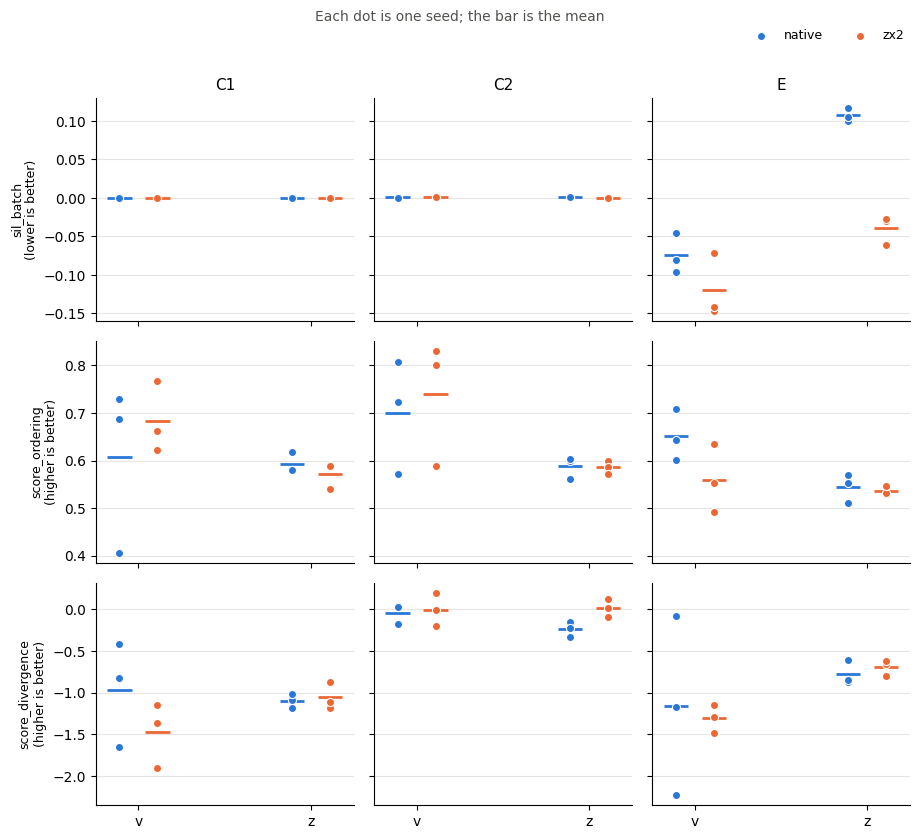

wrote /Users/alanxie/CodingProjects/Columbia/Azizi Lab/Spatial Nut Carcinoma/decipher-bc-methods/Data Analysis/aml_outputs/aml_per_seed.png


In [12]:
# sharey="row": each metric gets ONE scale across fits. Without it C1/C2 noise
# (+/-0.0004 sil_batch) is drawn as tall as E's real 0.15 separation, which invites a
# comparison the numbers do not support.
# Dots, not bars: these scores are not anchored at zero (divergence runs
# negative), so a bar from zero would encode a magnitude that does not exist.
spaces = ["decipher_v", "decipher_z"]
fits   = [f for f in ["C1", "C2", "E"] if f in set(r.fit)]

fig, axes = plt.subplots(len(METRICS), len(fits),
                         figsize=(3.1 * len(fits), 2.7 * len(METRICS)),
                         sharex=True, sharey="row", squeeze=False)

for i, metric in enumerate(METRICS):
    for j, fit in enumerate(fits):
        ax = axes[i][j]
        for k, space in enumerate(spaces):
            for off, arm in zip((-0.11, 0.11), ("native", "zx2")):
                v = r[(r.fit == fit) & (r.space == space) & (r.arm == arm)][metric].to_numpy()
                if not len(v):
                    continue
                ax.scatter(np.full(len(v), k + off), v, s=34,
                           color=ARM_COLOR[arm], edgecolor="white", linewidth=0.8,
                           zorder=3, label=arm if (i == 0 and j == 0 and k == 0) else None)
                ax.hlines(v.mean(), k + off - 0.07, k + off + 0.07,
                          color=ARM_COLOR[arm], linewidth=2, zorder=2)
        ax.set_xticks(range(len(spaces)))
        ax.set_xticklabels([s.replace("decipher_", "") for s in spaces])
        ax.grid(axis="y", color="#e6e5e2", linewidth=0.8)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)
        if j == 0:
            ax.set_ylabel(f"{metric}\n({BETTER[metric]} is better)", fontsize=9)
        if i == 0:
            ax.set_title(fit, fontsize=11)

fig.legend(loc="upper right", frameon=False, ncols=2, fontsize=9,
           bbox_to_anchor=(0.99, 1.02))
fig.suptitle("Each dot is one seed; the bar is the mean", fontsize=10, y=1.03, color="#52514e")
fig.tight_layout()
fig.savefig(OUT_DIR / "aml_per_seed.png", dpi=200, bbox_inches="tight")
plt.show()
print("wrote", OUT_DIR / "aml_per_seed.png")

---
## 14. Pseudotime — learned, and what stands in for ground truth

**There is no latent pseudotime on this data.** `latent_t` is a *simulator* variable, written
by `Data/Simulated Data/Simulated Data Generation/simulated_data_pipeline_*.py`. GSE298955
is real tissue; no cell carries a true time. Confirmed on the trained objects — `obs` has no
`latent_t`. So the "learned vs latent" plot from the sweeps has no counterpart here.

What does exist:

**Learned pseudotime** is `obs["decipher_time"]`, and it is not written by `decipher_train` —
it needs a trajectory first. Three calls, both arms expose all of them:

```
cell_clusters(adata, rep_key="decipher_z")   ->  obs["decipher_clusters"]
trajectories(adata, TConfig(...), TConfig(...))  ->  uns["decipher"]["trajectories"]
decipher_time(adata)                         ->  obs["decipher_time"]
```

The two trajectories use the **paper's own markers**, from `analysis-aml1.ipynb`:
`AVP -> MPO` on the healthy cells and `AVP -> CD68` on the leukemic cells. All three genes
survive our gene filtering.

**The stand-in for ground truth** is `cell_type_merged`. The paper's manual staging
`immature -> blast0 -> blast1 -> blast2 -> blast3` is an *ordinal* maturation ordering, so
mapping it to 0..4 gives the thing `latent_t` gave in the sweeps: an independent ordering to
correlate the learned time against. The Spearman correlation below is the real-data analogue
of `rho`.

Two honest caveats. The staging is hand-annotated, not measured, so it is a weaker reference
than a simulator's ground truth. And it is defined only on the leukemic cells — healthy cells
are all `immature` — so the correlation is computed within `origin == "perturbed"`.

**Cost.** `cell_clusters` runs a neighbour graph and Leiden on `decipher_z` for 59,499 cells,
a few minutes per object. Defaults to fit E at one seed (2 objects); widen `PT_SEEDS` to
cover more.

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import decipher as dc_native
import decipher_zx2 as dc_zx2

# Redefined here so this section runs without section 9 (which would reload all 18
# trained objects just to hand back this dict).
ARMS = {"native": dict(module=dc_native), "zx2": dict(module=dc_zx2)}

PT_FIT   = os.environ.get("AML_PT_FIT", "E")
PT_SEEDS = [int(s) for s in os.environ.get("AML_PT_SEEDS", str(SEEDS[0])).split(",")]

STAGE_ORDER = ["immature", "blast0", "blast1", "blast2", "blast3"]
STAGE_RANK  = {s: i for i, s in enumerate(STAGE_ORDER)}

# Ordinal ramp: one hue, light->dark, starting at step 250 (the lightest step that still
# clears 2:1 on a light surface). Healthy takes the next categorical slot, since it is a
# different kind of thing rather than another step of the same scale.
STAGE_COLOR = {
    "immature": "#86b6ef", "blast0": "#5598e7", "blast1": "#2a78d6",
    "blast2": "#1c5cab",   "blast3": "#104281", "healthy": "#eb6834",
}
TIME_CMAP = LinearSegmentedColormap.from_list(
    "decipher_blue", ["#cde2fb", "#86b6ef", "#3987e5", "#2a78d6", "#1c5cab", "#0d366b"])


def add_pseudotime(adata, module):
    """cell_clusters -> trajectories -> decipher_time, using the paper's markers."""
    tl = module.tl
    tl.cell_clusters(adata, rep_key="decipher_z", seed=0)
    tl.trajectories(
        adata,
        tl.TConfig("healthy",  start_cluster_or_marker="AVP", end_cluster_or_marker="MPO",
                   subset_col="origin", subset_val="normal"),
        tl.TConfig("leukemic", start_cluster_or_marker="AVP", end_cluster_or_marker="CD68",
                   subset_col="origin", subset_val="perturbed"),
    )
    tl.decipher_time(adata)
    return adata


pt = {}
for seed in PT_SEEDS:
    for arm_name, arm in ARMS.items():
        path = OUT_DIR / f"{PT_FIT}_{arm_name}_seed{seed}.h5ad"
        a = sc.read_h5ad(path)
        t0 = time.time()
        add_pseudotime(a, arm["module"])
        a.obs["stage_display"] = np.where(a.obs["origin"].to_numpy() == "normal",
                                          "healthy", a.obs["cell_type_merged"].to_numpy())
        pt[(arm_name, seed)] = a
        print(f"  {PT_FIT}/{arm_name}/seed{seed}: decipher_time in "
              f"{(time.time() - t0) / 60:.1f} min, "
              f"{a.obs['decipher_time'].notna().sum():,d} cells timed")

2026-09-29 15:52:53,142 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-09-29 15:52:53,145 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-09-29 15:52:57,187 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 1.0.
2026-09-29 15:53:12,671 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.
2026-09-29 15:53:12,741 | INFO : Trajectory healthy : ['18', '15'])
2026-09-29 15:53:12,744 | INFO : Added trajectory healthy to `adata.uns['decipher']['trajectories']`.
2026-09-29 15:53:13,183 | INFO : Trajectory leukemic : ['4', '22', '0', '20', '9', '1', '6', '7', '14'])
2026-09-29 15:53:13,187 | INFO : Added trajectory leukemic to `adata.uns['decipher']['trajectories']`.
2026-09-29 15:53:13,218 | INFO : Added `.obs['decipher_time']`: the decipher time of each cell.


  E/native/seed0: decipher_time in 0.3 min, 30,598 cells timed


2026-09-29 15:53:15,551 | INFO : Clustering cells using scanpy Leiden algorithm.
2026-09-29 15:53:15,551 | INFO : Step 1: Computing neighbors with `sc.pp.neighbors`, with the representation decipher_z.
2026-09-29 15:53:18,784 | INFO : Step 2: Computing clusters with `sc.tl.leiden`, and resolution 1.0.
2026-09-29 15:53:48,879 | INFO : Added `.obs['decipher_clusters']`: the cluster labels.
2026-09-29 15:53:48,980 | INFO : Trajectory healthy : ['18', '8'])
2026-09-29 15:53:48,982 | INFO : Added trajectory healthy to `adata.uns['decipher']['trajectories']`.
2026-09-29 15:53:49,443 | INFO : Trajectory leukemic : ['4', '10', '19', '7', '3', '6'])
2026-09-29 15:53:49,445 | INFO : Added trajectory leukemic to `adata.uns['decipher']['trajectories']`.
2026-09-29 15:53:49,466 | INFO : Added `.obs['decipher_time']`: the decipher time of each cell.


  E/zx2/seed0: decipher_time in 0.6 min, 22,438 cells timed


In [14]:
from scipy.stats import spearmanr

rows = []
for (arm_name, seed), a in pt.items():
    m = (a.obs["origin"].to_numpy() == "perturbed") & a.obs["decipher_time"].notna().to_numpy()
    rank = a.obs.loc[m, "cell_type_merged"].map(STAGE_RANK).to_numpy(dtype=float)
    keep = ~np.isnan(rank)
    rho, p = spearmanr(a.obs.loc[m, "decipher_time"].to_numpy()[keep], rank[keep])
    rows.append({"fit": PT_FIT, "arm": arm_name, "seed": seed,
                 "n_cells": int(keep.sum()), "spearman_rho_vs_stage": round(rho, 4),
                 "abs_rho": round(abs(rho), 4)})

pt_scores = pd.DataFrame(rows)
pt_scores.to_csv(OUT_DIR / "aml_pseudotime_vs_stage.csv", index=False)
print("Spearman of decipher_time against the paper's ordinal staging, leukemic cells only.")
print("Sign is arbitrary -- the trajectory direction is not fixed -- so read |rho|.\n")
print(pt_scores.to_string(index=False))

Spearman of decipher_time against the paper's ordinal staging, leukemic cells only.
Sign is arbitrary -- the trajectory direction is not fixed -- so read |rho|.

fit    arm  seed  n_cells  spearman_rho_vs_stage  abs_rho
  E native     0    28018                 0.9583   0.9583
  E    zx2     0    20069                 0.8569   0.8569


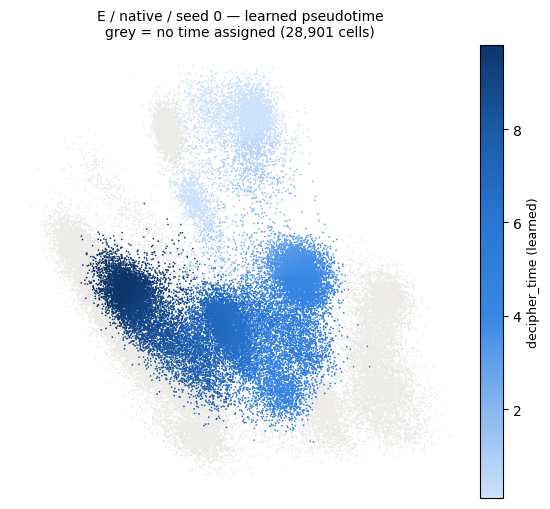

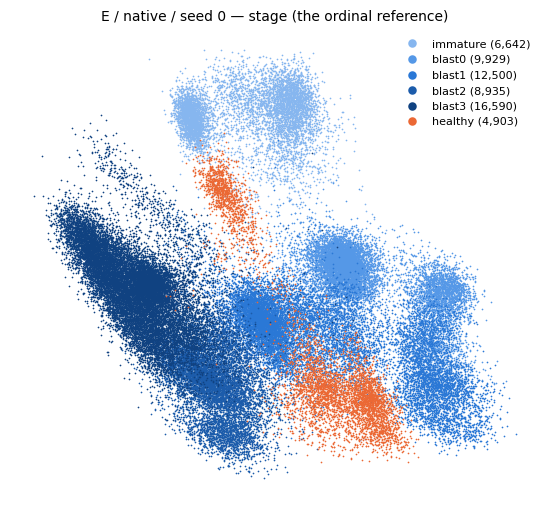

wrote aml_pseudotime_E_native_seed0_time.png and _stage.png


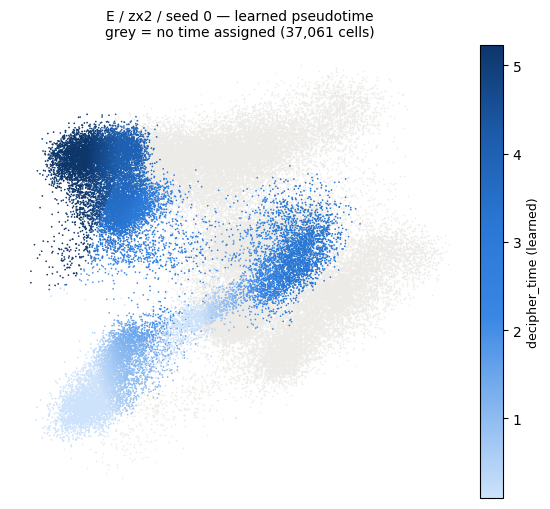

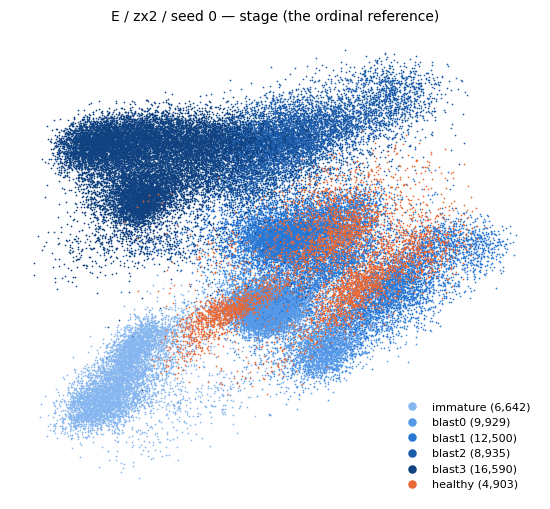

wrote aml_pseudotime_E_zx2_seed0_time.png and _stage.png


In [15]:
# One figure per image: each object gets a learned-time view and a stage view, saved
# separately. STEM names the file, so nothing overwrites anything else.
for (arm_name, seed), a in sorted(pt.items()):
    v = a.obsm["decipher_v"]
    stem = f"{PT_FIT}_{arm_name}_seed{seed}"

    # --- learned pseudotime -------------------------------------------------------
    fig, ax = plt.subplots(figsize=(5.6, 5.2))
    t = a.obs["decipher_time"].to_numpy(dtype=float)
    ok = ~np.isnan(t)
    ax.scatter(v[~ok, 0], v[~ok, 1], s=1.5, c="#ecebe8", linewidths=0, rasterized=True)
    s_ = ax.scatter(v[ok, 0], v[ok, 1], s=1.5, c=t[ok], cmap=TIME_CMAP,
                    linewidths=0, rasterized=True)
    cb = fig.colorbar(s_, ax=ax, fraction=0.046, pad=0.02)
    cb.set_label("decipher_time (learned)", fontsize=9)
    ax.set_title(f"{PT_FIT} / {arm_name} / seed {seed} — learned pseudotime\n"
                 f"grey = no time assigned ({(~ok).sum():,d} cells)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"aml_pseudotime_{stem}_time.png", dpi=200, bbox_inches="tight")
    plt.show()

    # --- stage, the ordinal reference ---------------------------------------------
    fig, ax = plt.subplots(figsize=(5.6, 5.2))
    for label in STAGE_ORDER + ["healthy"]:
        m = (a.obs["stage_display"].to_numpy() == label)
        if not m.any():
            continue
        ax.scatter(v[m, 0], v[m, 1], s=1.5, color=STAGE_COLOR[label], linewidths=0,
                   rasterized=True, label=f"{label} ({m.sum():,d})")
    ax.legend(frameon=False, fontsize=8, markerscale=5, loc="best")
    ax.set_title(f"{PT_FIT} / {arm_name} / seed {seed} — stage (the ordinal reference)",
                 fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    fig.savefig(OUT_DIR / f"aml_pseudotime_{stem}_stage.png", dpi=200, bbox_inches="tight")
    plt.show()

    print(f"wrote aml_pseudotime_{stem}_time.png and _stage.png")

---
## 15. Embeddings per arm and per seed

`decipher_v` for every seed of one fit, coloured by the batch key. Three seeds side by side
is the point: if the arms differ, the difference should survive re-initialisation, and if a
seed looks unlike its siblings that is worth knowing before any of it is interpreted.

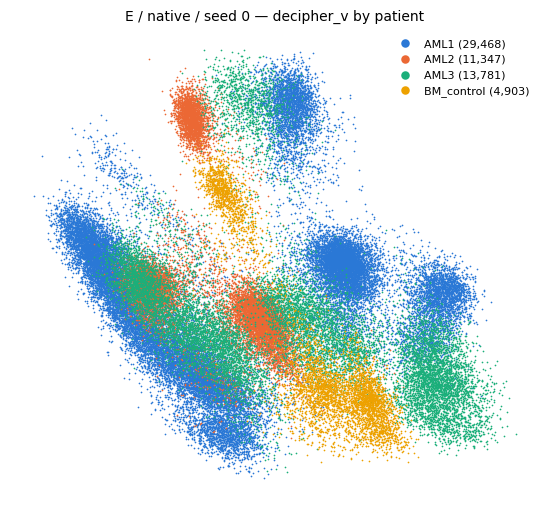

wrote aml_embeddings_E_native_seed0.png


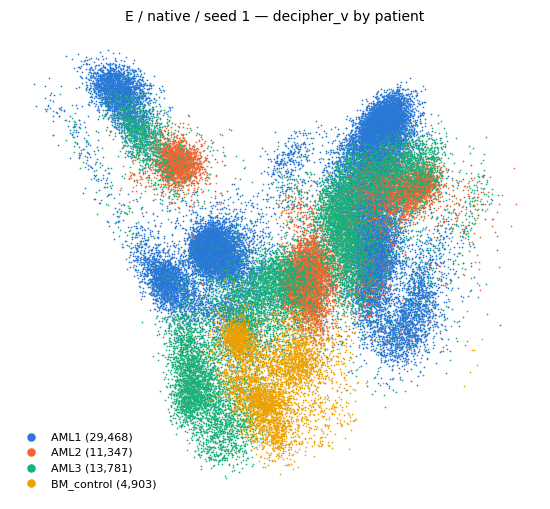

wrote aml_embeddings_E_native_seed1.png


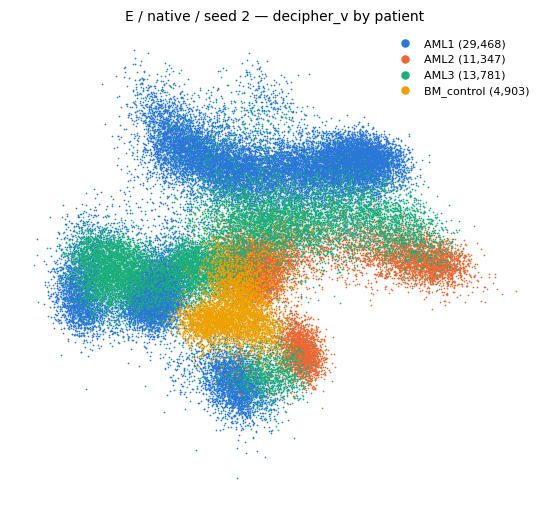

wrote aml_embeddings_E_native_seed2.png


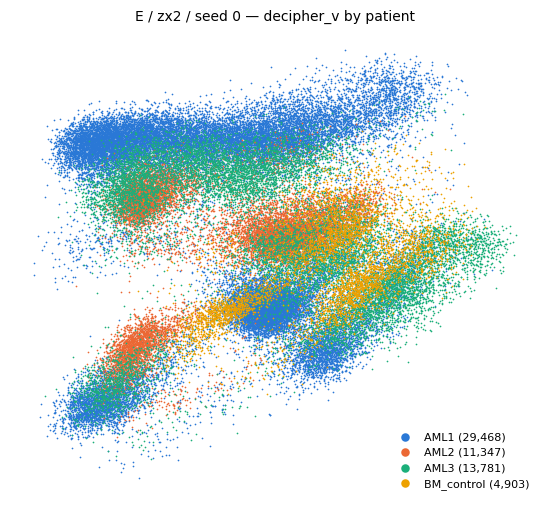

wrote aml_embeddings_E_zx2_seed0.png


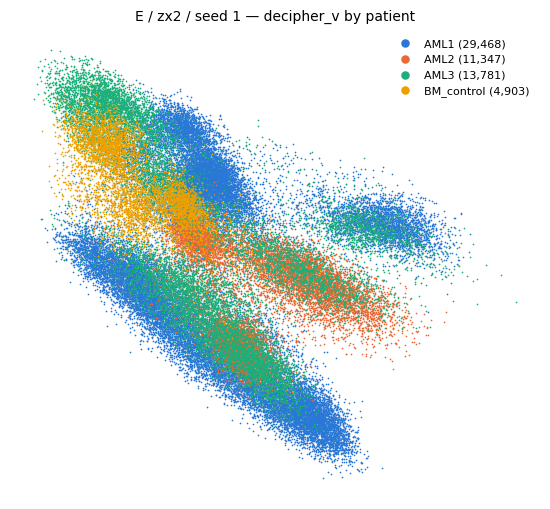

wrote aml_embeddings_E_zx2_seed1.png


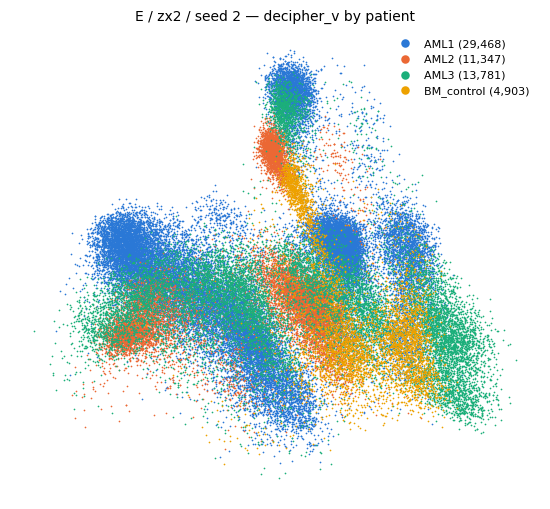

wrote aml_embeddings_E_zx2_seed2.png


In [16]:
import matplotlib.pyplot as plt

EMB_FIT = os.environ.get("AML_EMB_FIT", "E")

# Fixed by the design in section 6; hard-coded so this cell does not need FITS, which
# would mean re-running the whole preprocessing chain just to read two strings.
FIT_BATCH_KEY = {"C1": "library", "C2": "library", "E": "patient"}
bk = FIT_BATCH_KEY[EMB_FIT]
_probe = sc.read_h5ad(OUT_DIR / f"{EMB_FIT}_native_seed{SEEDS[0]}.h5ad")
levels = list(_probe.obs[bk].astype("category").cat.categories)
del _probe

# categorical slots in fixed order, never cycled
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
LEVEL_COLOR = {lv: SLOTS[i] for i, lv in enumerate(levels)}

# One figure per image: one arm, one seed, one file.
for arm_name in ARMS:
    for seed in SEEDS:
        a = sc.read_h5ad(OUT_DIR / f"{EMB_FIT}_{arm_name}_seed{seed}.h5ad")
        v = a.obsm["decipher_v"]
        fig, ax = plt.subplots(figsize=(5.6, 5.2))
        for lv in levels:
            m = (a.obs[bk].to_numpy() == lv)
            if not m.any():
                continue
            ax.scatter(v[m, 0], v[m, 1], s=1.5, color=LEVEL_COLOR[lv], linewidths=0,
                       rasterized=True, label=f"{lv} ({m.sum():,d})")
        ax.legend(frameon=False, fontsize=8, markerscale=5, loc="best")
        ax.set_title(f"{EMB_FIT} / {arm_name} / seed {seed} — decipher_v by {bk}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        for side in ("top", "right", "left", "bottom"):
            ax.spines[side].set_visible(False)
        fig.tight_layout()
        out = OUT_DIR / f"aml_embeddings_{EMB_FIT}_{arm_name}_seed{seed}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        plt.show()
        print("wrote", out.name)

---
## 16. Is there a fork? — the eight benchmark groups, measured

Sections 13-15 show patients and stages. Neither shows the thing the divergence score is
actually about, which is whether the two origins **share a root and separate at the tips**.
This section draws and measures that directly.

`compute_location_score` builds eight groups and writes them to `obs["benchmark_group"]`:
healthy `immature` cells split by marker into `normal_stage1` (CD34+), `normal_stage2`
(neither), `normal_stage3` (MPO+), and the leukemic cells as `perturbed_immature` plus
`perturbed_blast0..3`. It writes them in memory during scoring, so they are **not** in the
saved `.h5ad` files — this section recomputes them.

**What a fork is, as a number.** Two of the 28 group pairs decide it:

| pair | declared | should be |
|---|---|---|
| `normal_stage1` ↔ `perturbed_immature` | **adjacent** (the shared root) | **small** |
| `normal_stage3` ↔ `perturbed_blast3` | not adjacent (the two tips) | **large** |

So `fork_ratio = d(tips) / d(root)`. Above 1 means the origins are closer at the root than at
the tips — a fork. At or below 1 means they are not forking: either the two arms run parallel
without a shared origin, or they lie on top of each other.

All distances are divided by `intrinsic_distance` (mean distance between two 2,000-cell
subsamples), the same normalisation the score uses, so the numbers are comparable across arms
and across embeddings of different scale.

In [17]:
import itertools
import scipy.spatial
import matplotlib.pyplot as plt
from location_score import compute_location_score

FORK_FIT   = os.environ.get("AML_FORK_FIT", "E")
FORK_SEEDS = [int(s) for s in os.environ.get("AML_FORK_SEEDS", str(SEEDS[0])).split(",")]
FORK_SPACE = os.environ.get("AML_FORK_SPACE", "decipher_z")   # where the readable effect was

GROUPS = ["normal_stage1", "normal_stage2", "normal_stage3",
          "perturbed_immature", "perturbed_blast0", "perturbed_blast1",
          "perturbed_blast2", "perturbed_blast3"]

# The seven pairs compute_location_score declares adjacent -- the expected chain.
CHAIN = [("normal_stage1", "normal_stage2"), ("normal_stage2", "normal_stage3"),
         ("normal_stage1", "perturbed_immature"), ("perturbed_immature", "perturbed_blast0"),
         ("perturbed_blast0", "perturbed_blast1"), ("perturbed_blast1", "perturbed_blast2"),
         ("perturbed_blast2", "perturbed_blast3")]

ROOT_PAIR = ("normal_stage1", "perturbed_immature")
TIP_PAIR  = ("normal_stage3", "perturbed_blast3")


def group_distance_table(adata, obsm_key):
    """Normalised mean pairwise distance between benchmark groups.

    Same arithmetic compute_location_score runs internally; it only returns the two
    aggregates, so the pairwise table is rebuilt here rather than re-derived differently.
    """
    compute_location_score(adata, obsm_key)          # writes obs["benchmark_group"]
    g = adata.obs["benchmark_group"].to_numpy()
    intrinsic = scipy.spatial.distance.cdist(
        sc.pp.subsample(adata, n_obs=2000, copy=True).obsm[obsm_key],
        sc.pp.subsample(adata, n_obs=2000, copy=True).obsm[obsm_key]).mean()

    coords = {name: adata.obsm[obsm_key][g == name] for name in GROUPS}
    d = {}
    for a_, b_ in itertools.combinations(GROUPS, 2):
        if not len(coords[a_]) or not len(coords[b_]):
            d[(a_, b_)] = d[(b_, a_)] = np.nan
            continue
        v = scipy.spatial.distance.cdist(coords[a_], coords[b_]).mean() / intrinsic
        d[(a_, b_)] = d[(b_, a_)] = v
    return d, {name: len(c) for name, c in coords.items()}


fork_rows, chain_rows, fork_objs = [], [], {}
for seed in FORK_SEEDS:
    for arm_name in ARMS:
        a = sc.read_h5ad(OUT_DIR / f"{FORK_FIT}_{arm_name}_seed{seed}.h5ad")
        d, sizes = group_distance_table(a, FORK_SPACE)
        fork_objs[(arm_name, seed)] = a

        root, tip = d[ROOT_PAIR], d[TIP_PAIR]
        fork_rows.append({"fit": FORK_FIT, "space": FORK_SPACE, "arm": arm_name, "seed": seed,
                          "d_root": round(root, 3), "d_tips": round(tip, 3),
                          "fork_ratio": round(tip / root, 2) if root else np.nan,
                          "fork?": "yes" if tip > root else "NO"})
        for p in CHAIN:
            chain_rows.append({"arm": arm_name, "seed": seed,
                               "adjacent pair": f"{p[0]} - {p[1]}", "distance": round(d[p], 3)})

fork = pd.DataFrame(fork_rows)
print(f"Group sizes ({FORK_FIT}): " + ", ".join(f"{k}={v:,d}" for k, v in sizes.items()))
print(f"\nFORK TEST in {FORK_SPACE} -- distances normalised by intrinsic_distance\n")
print(fork.to_string(index=False))
fork.to_csv(OUT_DIR / "aml_fork_test.csv", index=False)
print("\nThe seven pairs the metric declares adjacent (the expected chain):\n")
print(pd.DataFrame(chain_rows).pivot_table(index="adjacent pair", columns=["arm", "seed"],
                                           values="distance").to_string())

Group sizes (E): normal_stage1=361, normal_stage2=3,091, normal_stage3=1,451, perturbed_immature=6,642, perturbed_blast0=9,929, perturbed_blast1=12,500, perturbed_blast2=8,935, perturbed_blast3=16,590

FORK TEST in decipher_z -- distances normalised by intrinsic_distance

fit      space    arm  seed  d_root  d_tips  fork_ratio fork?
  E decipher_z native     0   0.866   1.240        1.43   yes
  E decipher_z    zx2     0   0.803   1.329        1.66   yes

The seven pairs the metric declares adjacent (the expected chain):

arm                                   native    zx2
seed                                       0      0
adjacent pair                                      
normal_stage1 - normal_stage2          0.535  0.602
normal_stage1 - perturbed_immature     0.866  0.803
normal_stage2 - normal_stage3          0.642  0.705
perturbed_blast0 - perturbed_blast1    0.849  0.846
perturbed_blast1 - perturbed_blast2    1.059  0.999
perturbed_blast2 - perturbed_blast3    0.771  0.953
pert

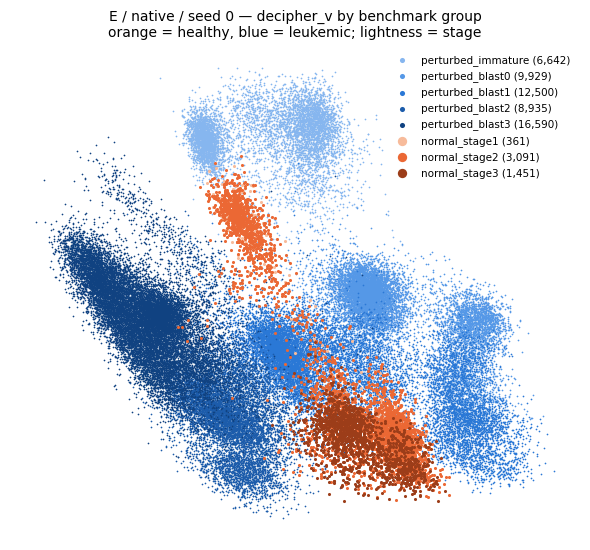

wrote aml_fork_E_native_seed0.png


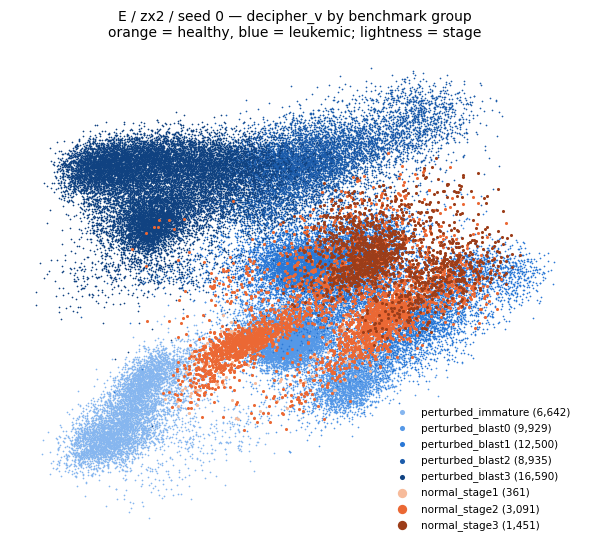

wrote aml_fork_E_zx2_seed0.png


In [18]:
# Two one-hue ramps, one per origin: healthy = orange, leukemic = blue. Reading origin off
# hue and stage off lightness is the encoding the fork question actually asks about.
# Blue steps are the reference palette's sequential ramp; the three orange steps are derived
# by lightness around its categorical orange slot (#eb6834) -- the validator needs node,
# which is not installed here, so treat those three as unvalidated.
GROUP_COLOR = {
    "normal_stage1": "#f7bb9b", "normal_stage2": "#eb6834", "normal_stage3": "#9c3d19",
    "perturbed_immature": "#86b6ef", "perturbed_blast0": "#5598e7",
    "perturbed_blast1": "#2a78d6", "perturbed_blast2": "#1c5cab",
    "perturbed_blast3": "#104281",
}

# One figure per image.
for (arm_name, seed), a in sorted(fork_objs.items()):
    v = a.obsm["decipher_v"]                # always plot v: decipher_z is 10-D
    g = a.obs["benchmark_group"].to_numpy()
    fig, ax = plt.subplots(figsize=(6.0, 5.6))
    ax.scatter(v[g == None, 0], v[g == None, 1], s=1.2, c="#ecebe8",
               linewidths=0, rasterized=True)
    # leukemic first, healthy on top: normal_stage1 is 361 cells against
    # perturbed_blast3's 16,590 and vanishes if it is drawn underneath.
    for name in ([x for x in GROUPS if x.startswith("perturbed")] +
                 [x for x in GROUPS if x.startswith("normal")]):
        m = (g == name)
        if not m.any():
            continue
        ax.scatter(v[m, 0], v[m, 1], s=5 if name.startswith("normal") else 1.5,
                   color=GROUP_COLOR[name], linewidths=0, rasterized=True,
                   label=f"{name} ({m.sum():,d})")
    ax.legend(frameon=False, fontsize=7.5, markerscale=3, loc="best", ncols=1)
    ax.set_title(f"{FORK_FIT} / {arm_name} / seed {seed} — decipher_v by benchmark group\n"
                 "orange = healthy, blue = leukemic; lightness = stage", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    fig.tight_layout()
    out = OUT_DIR / f"aml_fork_{FORK_FIT}_{arm_name}_seed{seed}.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print("wrote", out.name)